# Monte Carlo Simulation

Neste notebook é realizada a simulação de risco de crédito da carteira construída nas etapas anteriores do projeto. Após a preparação dos dados e a estimativa dos componentes fundamentais do risco — Probability of Default (PD), Loss Given Default (LGD) e Exposure at Default (EAD) — foi aplicada uma simulação de Monte Carlo para gerar diferentes cenários de inadimplência.

A partir dessas simulações é possível estimar a distribuição de perdas da carteira e calcular métricas amplamente utilizadas na gestão de risco financeiro, como Expected Loss, Credit Value at Risk (VaR) e Expected Shortfall.

A perda associada a cada contrato é determinada pela relação entre exposição, severidade da perda e ocorrência de default:

Loss = Default × LGD × EAD

A simulação foi executada com 10.000 cenários, permitindo avaliar tanto o comportamento médio da carteira quanto eventos de perda extrema.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carregar carteira

In [2]:
portfolio = pd.read_parquet("../data/processed/credit_portfolio_simulation.parquet")

portfolio.head()

,EAD,PD,LGD,expected_loss
0,3600.0,0.324511,0.520068,607.563973
1,24700.0,0.246653,0.443429,2701.516498
2,20000.0,0.324511,0.538235,3493.263610
3,10400.0,0.324511,0.335353,1131.785797
4,11950.0,0.324511,0.708696,2748.257591


### Estatísticas da carteira

In [3]:
print("Número de contratos:", len(portfolio))
print("Exposição total:", portfolio['EAD'].sum())

print("PD média:", portfolio['PD'].mean())
print("LGD média:", portfolio['LGD'].mean())

Número de contratos: 597989
Exposição total: 8897981225.0
PD média: 0.277093662080568
LGD média: 0.45024531128228057


### Expected Loss

In [4]:
portfolio['EL'] = (
    portfolio['PD'] *
    portfolio['LGD'] *
    portfolio['EAD']
)

expected_loss = portfolio['EL'].sum()

print("Expected Loss da carteira:", expected_loss)

Expected Loss da carteira: 1100174172.8295665


### Configurar Monte Carlo

In [6]:
n_simulations = 10000

losses = np.zeros(n_simulations)

### Simulação Monte Carlo

In [7]:
EAD = portfolio['EAD'].values
PD = portfolio['PD'].values
LGD = portfolio['LGD'].values


for i in range(n_simulations):

    # sorteio de default
    default_sim = np.random.binomial(1, PD)

    # cálculo da perda
    loss = default_sim * LGD * EAD

    # perda total da carteira
    losses[i] = loss.sum()

### Distribuição de perdas

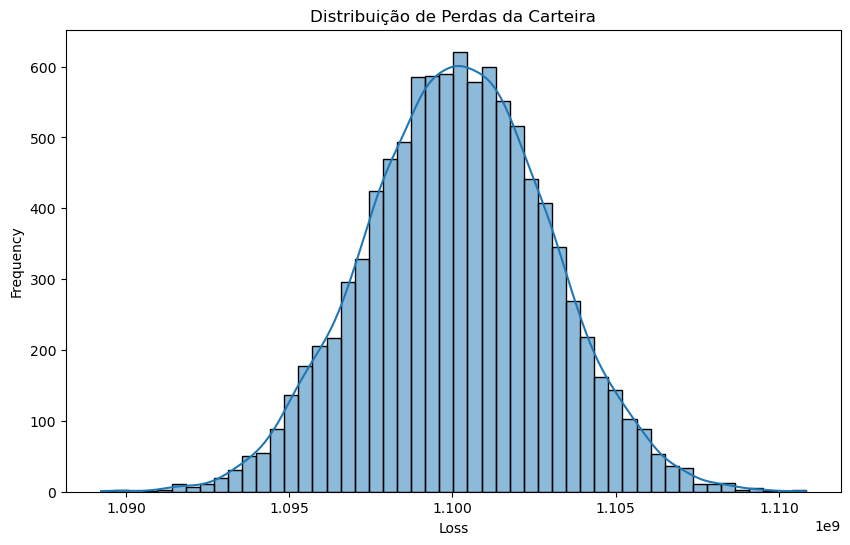

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    losses,
    bins=50,
    kde=True
)

plt.title("Distribuição de Perdas da Carteira")
plt.xlabel("Loss")
plt.ylabel("Frequency")

plt.show()

### Credit VaR

In [9]:
var_95 = np.percentile(losses, 95)
var_99 = np.percentile(losses, 99)

print("Credit VaR 95%:", var_95)
print("Credit VaR 99%:", var_99)

Credit VaR 95%: 1104781458.7684574
Credit VaR 99%: 1106689299.9371192


### Gráfico do VaR

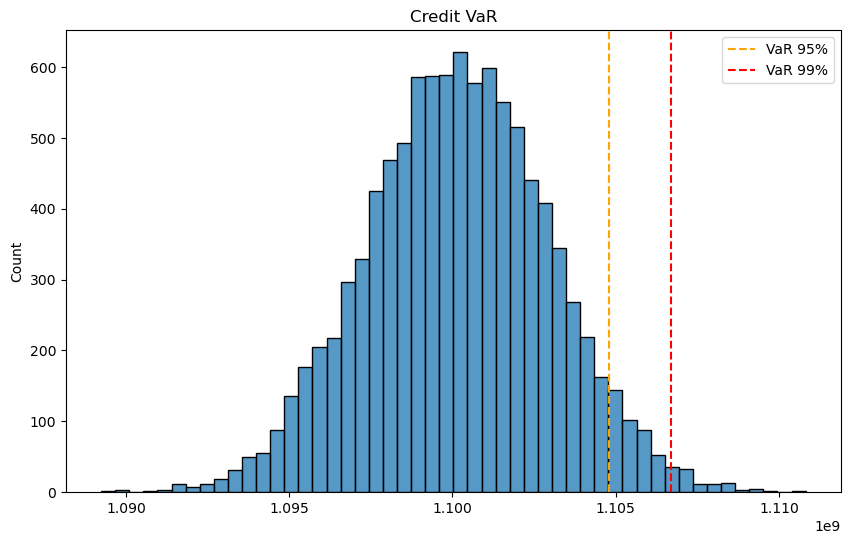

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(losses, bins=50)

plt.axvline(
    var_95,
    color='orange',
    linestyle='--',
    label='VaR 95%'
)

plt.axvline(
    var_99,
    color='red',
    linestyle='--',
    label='VaR 99%'
)

plt.title("Credit VaR")

plt.legend()

plt.show()

### Expected Shortfall

In [11]:
tail_losses = losses[losses >= var_99]

expected_shortfall = tail_losses.mean()

print("Expected Shortfall 99%:", expected_shortfall)

Expected Shortfall 99%: 1107628501.8388433


# Conclusão

A simulação Monte Carlo permitiu estimar a distribuição de perdas da carteira de crédito analisada.

A carteira apresenta exposição total de aproximadamente **8,9 bilhões**, com **Expected Loss estimada em cerca de 1,10 bilhão**, representando o nível médio de perdas esperado com base nas probabilidades de default e severidade de perda assumidas no modelo.

A análise de risco extremo indicou um **Credit VaR de aproximadamente 1,104 bilhão no nível de confiança de 95%** e **1,106 bilhão no nível de 99%**, representando as perdas máximas esperadas em cenários adversos dentro desses níveis de confiança.

O **Expected Shortfall ao nível de 99% foi estimado em aproximadamente 1,107 bilhão**, indicando a severidade média das perdas nos cenários mais extremos da distribuição.

De forma geral, os resultados mostram uma distribuição de perdas relativamente concentrada em torno da perda esperada, sugerindo baixa dispersão entre cenários simulados sob as premissas adotadas. A abordagem de simulação permite avaliar o risco da carteira de forma probabilística e fornece métricas importantes para análise e gestão de risco de crédito em nível de portfólio.